# Comparing Attention-MLP vs Attention + 1D-CNN

Run `01_attention_mlp.ipynb` and `02_attention_cnn.ipynb` first &mdash; each saves its metrics to
`../results/*.json`. This notebook just loads both and compares them side by side.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("../results/attention_mlp_results.json") as f:
    mlp_results = json.load(f)

with open("../results/attention_cnn_results.json") as f:
    cnn_results = json.load(f)

def flatten(r):
    return dict(
        Architecture=r["architecture"],
        Params=r["n_params"],
        Train_Time_s=r["train_time_s"],
        Sol_MAE=round(r["solubility"]["MAE"], 4),
        Sol_RMSE=round(r["solubility"]["RMSE"], 4),
        Sol_R2=round(r["solubility"]["R2"], 4),
        BBB_Acc=round(r["bbb"]["Accuracy"], 4),
        BBB_AUC=round(r["bbb"]["ROC_AUC"], 4),
        Tox_Acc=round(r["toxicity"]["Accuracy"], 4),
        Tox_AUC=round(r["toxicity"]["ROC_AUC"], 4),
    )

comparison = pd.DataFrame([flatten(mlp_results), flatten(cnn_results)])
comparison


,Architecture,Params,Train_Time_s,Sol_MAE,Sol_RMSE,Sol_R2,BBB_Acc,BBB_AUC,Tox_Acc,Tox_AUC
0,Attention-MLP,28835,232.1,0.8409,1.2168,0.7458,0.8649,0.8773,0.7156,0.7500
1,Attention + 1D-CNN,13124,92.4,0.9218,1.2752,0.7209,0.8750,0.8767,0.7122,0.7491


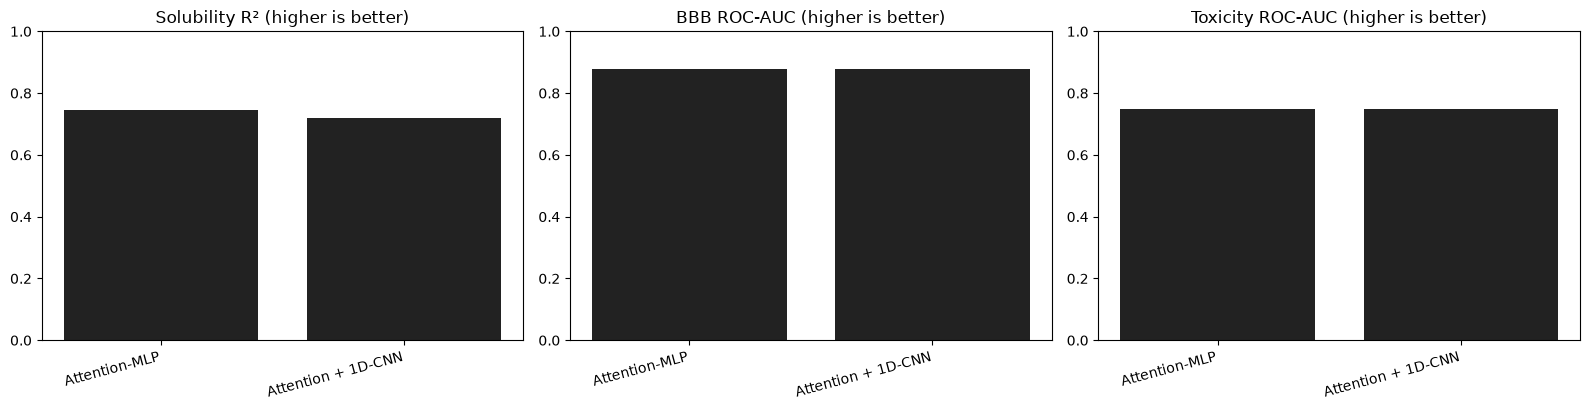

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
archs = comparison["Architecture"]
x = np.arange(len(archs))

axes[0].bar(x, comparison["Sol_R2"], color="#222222")
axes[0].set_xticks(x); axes[0].set_xticklabels(archs, rotation=15, ha="right")
axes[0].set_title("Solubility R\u00b2 (higher is better)"); axes[0].set_ylim(0, 1)

axes[1].bar(x, comparison["BBB_AUC"], color="#222222")
axes[1].set_xticks(x); axes[1].set_xticklabels(archs, rotation=15, ha="right")
axes[1].set_title("BBB ROC-AUC (higher is better)"); axes[1].set_ylim(0, 1)

axes[2].bar(x, comparison["Tox_AUC"], color="#222222")
axes[2].set_xticks(x); axes[2].set_xticklabels(archs, rotation=15, ha="right")
axes[2].set_title("Toxicity ROC-AUC (higher is better)"); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


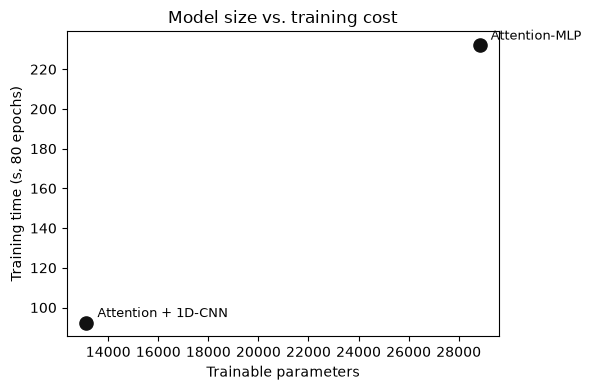

Saved ../results/architecture_comparison.csv


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(comparison["Params"], comparison["Train_Time_s"], s=90, color="#111111")
for _, row in comparison.iterrows():
    ax.annotate(row["Architecture"], (row["Params"], row["Train_Time_s"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Trainable parameters")
ax.set_ylabel("Training time (s, 80 epochs)")
ax.set_title("Model size vs. training cost")
plt.tight_layout()
plt.show()

comparison.to_csv("../results/architecture_comparison.csv", index=False)
print("Saved ../results/architecture_comparison.csv")


### Reading the comparison

Both models share the same 12 RDKit descriptors, the same masked multi-task loss, and the
same train/val/test split &mdash; the only difference is architecture. A few things worth checking
when you look at your own run:

- **Accuracy/R&sup2;/AUC** &mdash; which architecture actually predicts better on held-out molecules?
- **Params vs. train time** &mdash; the CNN+attention model has roughly half the parameters of the
  Transformer-style Attention-MLP and (on CPU) trains noticeably faster; is that trade-off worth
  it for the accuracy difference you see?
- If the plain-tabular Attention-MLP doesn't clearly win despite the extra self-attention
  machinery, that's a known pattern in tabular deep learning &mdash; attention tends to need either
  more data or richer raw input (e.g. fingerprints, molecular graphs) to show a real advantage
  over simpler architectures.
